# Patient Readmission Risk Prediction
## 01 - Data Understanding

This notebook performs initial exploration and understanding of the
Diabetes 130-US Hospitals dataset.

The objective is to predict whether a patient will be readmitted
within 30 days after discharge.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv("../data/raw/diabetic_data.csv")

In [79]:
df.shape

(101766, 50)

In [80]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [81]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [83]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [84]:
missing = (df == "?").sum().sort_values(ascending=False)
missing[missing > 0]

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

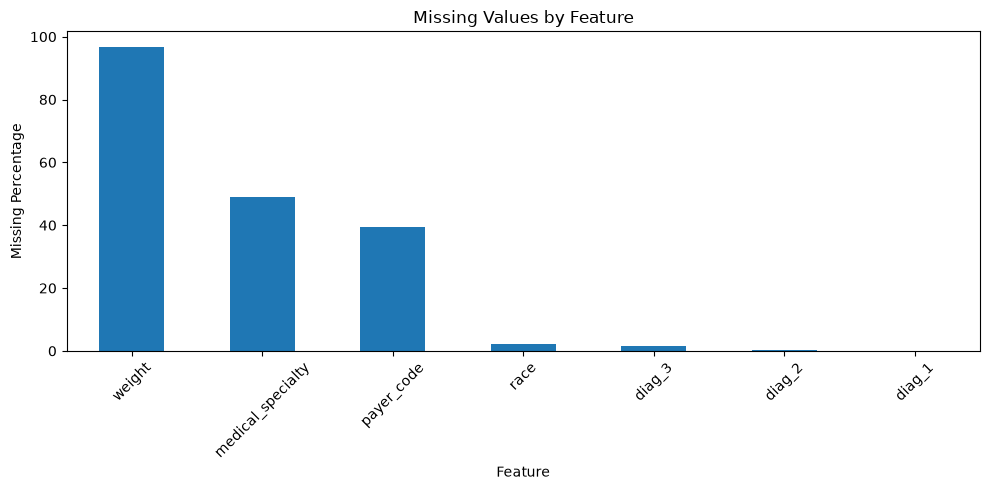

In [85]:
missing_percent = (
    (df == "?").mean() * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Missing Values by Feature")
plt.ylabel("Missing Percentage")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [87]:
print("Unique encounters:", df["encounter_id"].nunique())
print("Unique patients:", df["patient_nbr"].nunique())

Unique encounters: 101766
Unique patients: 71518


In [88]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [89]:
target_percent = df["readmitted"].value_counts(normalize=True) * 100

print(target_percent.round(2))

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


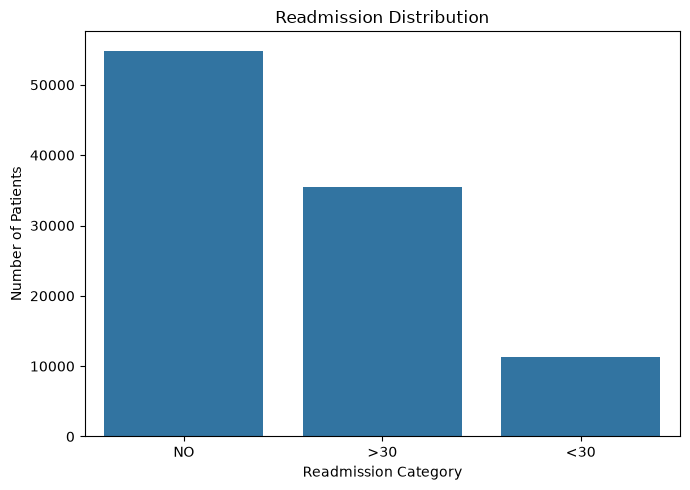

In [90]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="readmitted")

plt.title("Readmission Distribution")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [91]:
df["age"].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

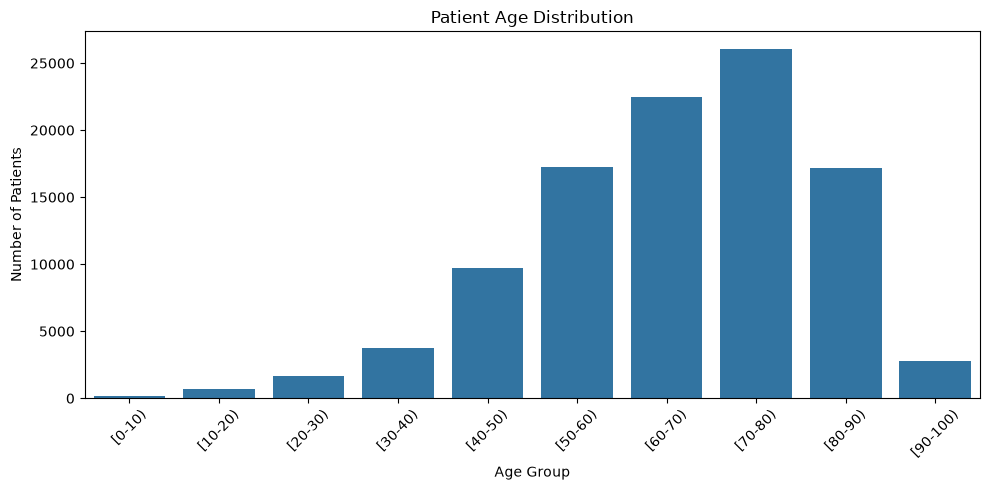

In [92]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="age", order=sorted(df["age"].unique()))

plt.title("Patient Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [93]:
df["gender"].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

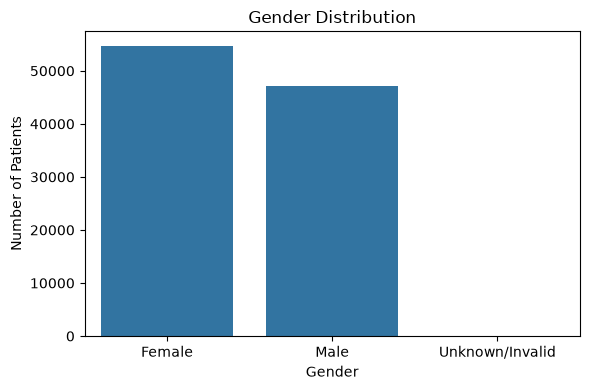

In [94]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [95]:
df["time_in_hospital"].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

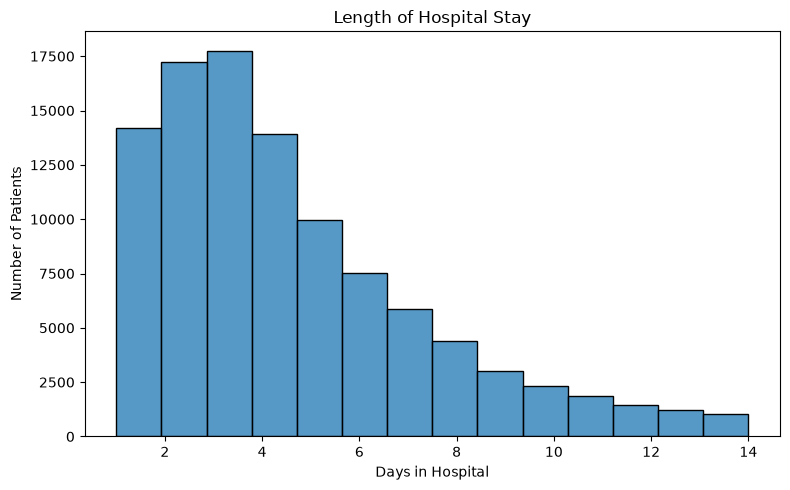

In [96]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="time_in_hospital",
    bins=14
)

plt.title("Length of Hospital Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [97]:
df["number_inpatient"].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

In [98]:
df["number_inpatient"].value_counts().sort_index().head(20)

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
Name: count, dtype: int64

In [99]:
df["num_medications"].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

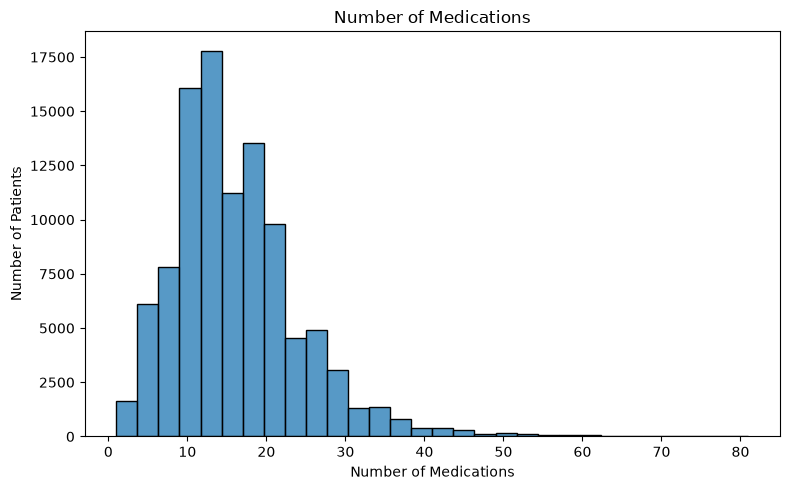

In [100]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="num_medications",
    bins=30
)

plt.title("Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [101]:
df[["diag_1", "diag_2", "diag_3"]].head()

,diag_1,diag_2,diag_3
0,250.83,?,?
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250


In [102]:
df["diag_1"].value_counts().head(20)

diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

In [103]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


## Initial Observations

- The dataset contains 101,766 hospital encounters and 50 variables.
- The target variable `readmitted` contains three categories: NO, >30, and <30.
- For this project, `<30` will represent readmission within 30 days.
- The dataset contains substantial missing information represented by `?`.
- `weight`, `medical_specialty`, and `payer_code` have particularly high missingness.
- `time_in_hospital` represents length of stay.
- `number_inpatient` provides information related to previous inpatient visits.
- `num_medications` can represent medication burden.
- Diagnosis information is available through `diag_1`, `diag_2`, and `diag_3`.
- The target is imbalanced, with fewer encounters being readmitted within 30 days.